# Depth GINN synthetic pretrain workflow 深度域合成预训练工作流

这个 notebook 用和 `05_Neural_Network_Training.ipynb` 类似的方式，走一遍 `ginn_depth` 新增的合成数据预训练流程。

核心流程是：

```text
真实 AI LFM / Vp LFM / mask trace
-> 随机 reflectivity，再递推并高通得到 logAI residual
-> target_ai = ai_lfm * exp(residual)
-> 根据配置生成 synthetic Vp
-> DepthForwardModel(target_ai, synthetic_vp)
-> synthetic seismic
-> 模型输入 synthetic seismic + LFM + mask + dynamic gain
-> residual loss + waveform loss
```

重新运行采样 cell 可以看到不同的合成 trace。

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from ginn.data import DYNAMIC_GAIN_LOG_CLIP
from ginn_depth.config import DepthGINNConfig
from ginn_depth.data import build_dataset
from ginn_depth.model import DilatedResNet1D
from ginn_depth.physics import DepthForwardModel
from ginn_depth.synthetic import SyntheticDepthTraceDataset

torch.set_grad_enabled(False)
print(repo_root)

C:\Users\WangQinZhuo\Program\libra_workflow_standardize


## 1) Load training config 加载训练配置

`experiments/ginn_depth/train.yaml` 里已经包含 synthetic pretrain 参数。这里先只加载配置并打印关键项。

In [2]:
config_path = repo_root / "experiments" / "ginn_depth" / "train.yaml"
cfg = DepthGINNConfig.from_yaml(config_path, base_dir=repo_root)

synthetic_keys = [
    "synthetic_pretrain_enabled",
    "synthetic_pretrain_epochs",
    "synthetic_traces_per_epoch",
    "synthetic_residual_max_abs",
    "synthetic_velocity_mode",
    "synthetic_vp_ai_slope",
    "synthetic_vp_ai_intercept",
    "synthetic_vp_blend_alpha",
    "synthetic_vp_smooth_samples",
    "synthetic_lambda_residual",
    "synthetic_lambda_waveform",
]

for key in synthetic_keys:
    print(f"{key}: {getattr(cfg, key)}")

synthetic_pretrain_enabled: True
synthetic_pretrain_epochs: 5
synthetic_traces_per_epoch: 8192
synthetic_residual_max_abs: 0.3
synthetic_velocity_mode: blend
synthetic_vp_ai_slope: 3.50498056307
synthetic_vp_ai_intercept: -4674.13994706
synthetic_vp_blend_alpha: 0.5
synthetic_vp_smooth_samples: 3
synthetic_lambda_residual: 1.0
synthetic_lambda_waveform: 0.2


## 2) Build real background dataset 构建真实背景数据

合成样本不是从零开始造一个地质模型，而是从真实训练集抽取背景 trace：

- `lfm_raw`: AI 低频模型
- `velocity_raw`: Vp 低频模型
- `mask / loss_mask / taper_weight`: 目标层约束
- `dynamic_gain`: 如果配置启用动态增益，也会一起复用

这一步会读取真实地震、LFM、层位和子波，耗时取决于数据体大小。

In [3]:
dataset_bundle = build_dataset(cfg)
train_dataset = dataset_bundle.train_dataset

print(f"train traces: {len(train_dataset):,}")
print(f"seis_rms: {train_dataset.seis_rms:.6g}")
print(f"lfm_scale: {train_dataset.lfm_scale:.6g}")
print(f"input channels: {train_dataset.input_channel_names}")
print(f"depth samples: {dataset_bundle.depth_axis_m.size:,}")

100%|██████████| 601/601 [00:02<00:00, 253.96it/s]


train traces: 429,263
seis_rms: 7334.79
lfm_scale: 16834.9
input channels: ('seismic', 'ai_lfm', 'mask', 'dynamic_gain_log_ratio')
depth samples: 551


## 3) Create synthetic dataset 创建合成数据集

`SyntheticDepthTraceDataset` 每次 `__getitem__` 都会重新随机抽一条真实背景 trace，先生成新的 reflectivity，再递推为 raw logAI，最后高通得到目标 logAI residual。

In [26]:
synthetic_dataset = SyntheticDepthTraceDataset(
    train_dataset,
    num_examples=cfg.synthetic_traces_per_epoch,
    residual_max_abs=cfg.synthetic_residual_max_abs,
    thin_bed_min_samples=cfg.synthetic_thin_bed_min_samples,
    thin_bed_max_samples=cfg.synthetic_thin_bed_max_samples,
    ai_min=cfg.ai_min,
    ai_max=cfg.ai_max,
    velocity_mode=cfg.synthetic_velocity_mode,
    vp_ai_slope=cfg.synthetic_vp_ai_slope,
    vp_ai_intercept=cfg.synthetic_vp_ai_intercept,
    vp_blend_alpha=cfg.synthetic_vp_blend_alpha,
    vp_smooth_samples=cfg.synthetic_vp_smooth_samples,
)

sample = synthetic_dataset[0]
for key, value in sample.items():
    if torch.is_tensor(value):
        print(f"{key:>16}: shape={tuple(value.shape)}, dtype={value.dtype}")

           input: shape=(4, 551), dtype=torch.float32
             obs: shape=(1, 551), dtype=torch.float32
            mask: shape=(1, 551), dtype=torch.bool
       loss_mask: shape=(1, 551), dtype=torch.bool
    taper_weight: shape=(1, 551), dtype=torch.float32
         lfm_raw: shape=(1, 551), dtype=torch.float32
    velocity_raw: shape=(1, 551), dtype=torch.float32
    dynamic_gain: shape=(1, 551), dtype=torch.float32
 target_residual: shape=(1, 551), dtype=torch.float32
       target_ai: shape=(1, 551), dtype=torch.float32


## 4) Visualize one synthetic trace 查看一条合成 trace

重新运行下面这个 cell，会得到新的随机 reflectivity、高通 residual 和 synthetic target。

Text(0.5, 0.98, 'Synthetic trace, velocity_mode=blend')

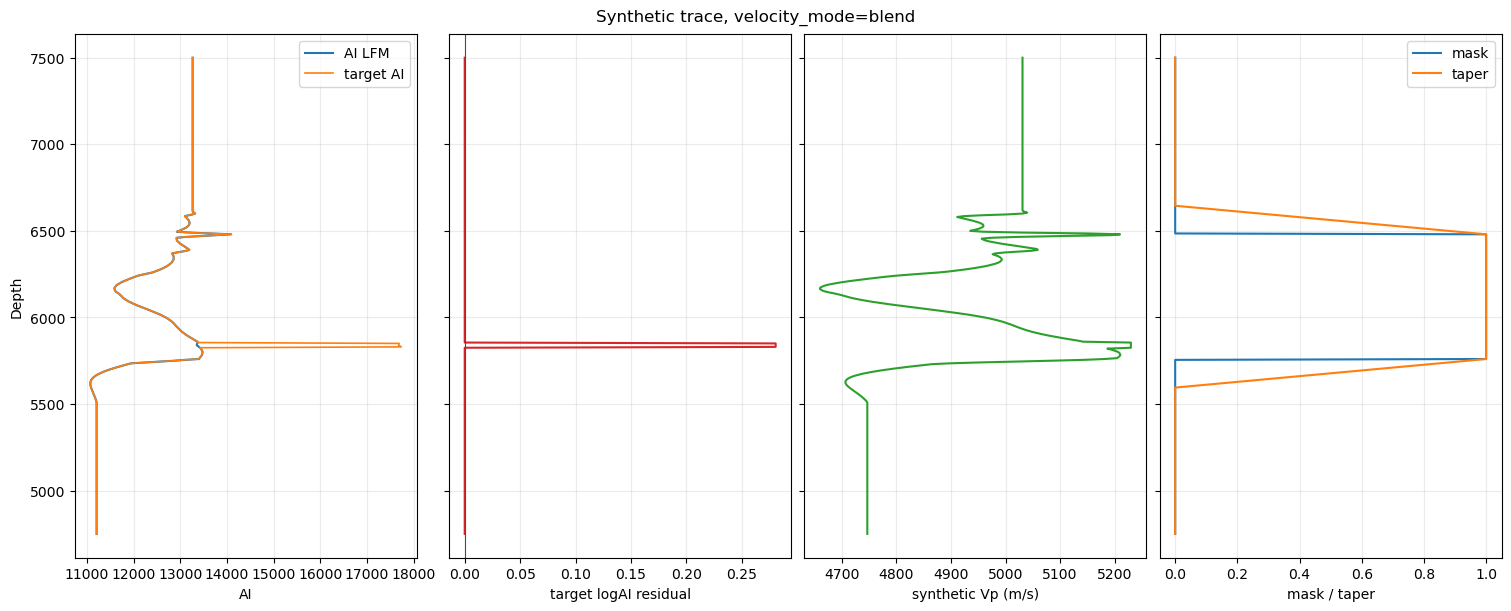

In [27]:
# Run this cell again to get a new synthetic trace.

sample = synthetic_dataset[0]
z = dataset_bundle.depth_axis_m

lfm_ai = sample["lfm_raw"].squeeze().numpy()
target_ai = sample["target_ai"].squeeze().numpy()
target_residual = sample["target_residual"].squeeze().numpy()
target_reflectivity = sample["target_reflectivity"].squeeze().numpy()
synthetic_vp = sample["velocity_raw"].squeeze().numpy()
mask = sample["mask"].squeeze().numpy().astype(bool)
taper = sample["taper_weight"].squeeze().numpy()

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True, constrained_layout=True)

axes[0].plot(lfm_ai, z, label="AI LFM")
axes[0].plot(target_ai, z, label="target AI", lw=1.2)
axes[0].set_xlabel("AI")
axes[0].legend()

axes[1].plot(target_residual, z, color="tab:red")
axes[1].axvline(0.0, color="0.3", lw=0.8)
axes[1].set_xlabel("target logAI residual")

axes[2].step(target_reflectivity, z[:-1], where="post", color="tab:orange")
axes[2].axvline(0.0, color="0.3", lw=0.8)
axes[2].set_xlabel("target reflectivity")

axes[3].plot(synthetic_vp, z, color="tab:green")
axes[3].set_xlabel("synthetic Vp (m/s)")

axes[4].plot(mask.astype(float), z, label="mask")
axes[4].plot(taper, z, label="taper")
axes[4].set_xlabel("mask / taper")
axes[4].legend()

for ax in axes:
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Depth")
fig.suptitle(f"Synthetic trace, velocity_mode={cfg.synthetic_velocity_mode}")

## 5) Forward model synthetic seismic 正演合成地震

这里用和训练一致的 `DepthForwardModel`：AI 控制反射系数，Vp 控制深度到时间的传播关系。

Text(0.5, 0.98, 'AI + Vp -> DepthForwardModel -> synthetic seismic')

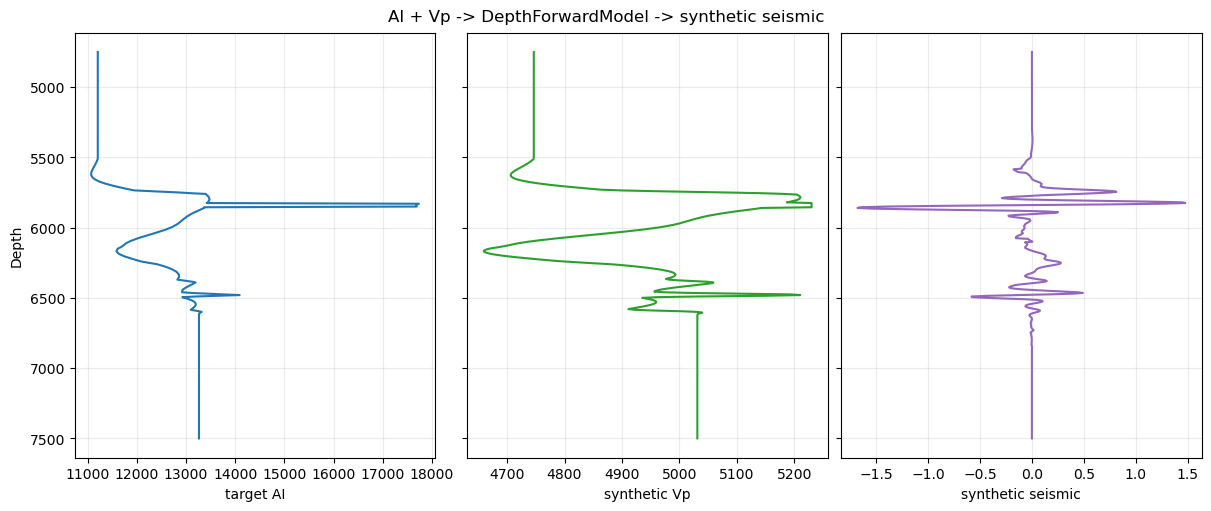

In [28]:
forward_model = DepthForwardModel(
    dataset_bundle.wavelet_time_s,
    dataset_bundle.wavelet_amp,
    depth_axis_m=dataset_bundle.depth_axis_m,
    amplitude_threshold=cfg.wavelet_amplitude_threshold,
).cpu()

target_ai_tensor = sample["target_ai"].unsqueeze(0)
vp_tensor = sample["velocity_raw"].unsqueeze(0)
dynamic_gain = sample.get("dynamic_gain")
dynamic_gain_tensor = dynamic_gain.unsqueeze(0) if dynamic_gain is not None else None

with torch.no_grad():
    target_seismic = forward_model(target_ai_tensor, vp_tensor, gain=dynamic_gain_tensor)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True, constrained_layout=True)
axes[0].plot(target_ai, z)
axes[0].set_xlabel("target AI")
axes[1].plot(synthetic_vp, z, color="tab:green")
axes[1].set_xlabel("synthetic Vp")
axes[2].plot(target_seismic.squeeze().numpy(), z, color="tab:purple")
axes[2].set_xlabel("synthetic seismic")

for ax in axes:
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Depth")
fig.suptitle("AI + Vp -> DepthForwardModel -> synthetic seismic")

## 6) Compose model input 组装网络输入

预训练时网络看到的输入通道要和真实训练一致：

- synthetic seismic
- optional AI LFM
- optional mask
- optional dynamic gain log-ratio

In [7]:
def compose_synthetic_input(seismic_norm, lfm_raw, core_mask, dynamic_gain):
    channels = [seismic_norm.squeeze(1)]
    if cfg.include_lfm_input:
        channels.append((lfm_raw / float(train_dataset.lfm_scale)).squeeze(1))
    if cfg.include_mask_input:
        channels.append(core_mask.float().squeeze(1))
    if cfg.include_dynamic_gain_input:
        if dynamic_gain is None:
            channels.append(torch.zeros_like(seismic_norm.squeeze(1)))
        else:
            median = train_dataset.dynamic_gain_median
            if median is None or median <= 0.0:
                median = 1.0
            gain_input = torch.log(torch.clamp(dynamic_gain, min=1e-6) / float(median)).clamp(
                -DYNAMIC_GAIN_LOG_CLIP,
                DYNAMIC_GAIN_LOG_CLIP,
            )
            channels.append(gain_input.squeeze(1))
    return torch.stack(channels, dim=1).float()

x = compose_synthetic_input(
    target_seismic,
    sample["lfm_raw"].unsqueeze(0),
    sample["mask"].unsqueeze(0),
    dynamic_gain_tensor,
)

print(f"model input shape: {tuple(x.shape)}")
print(f"configured in_channels: {cfg.in_channels}")
print(f"channel names: {train_dataset.input_channel_names}")

model input shape: (1, 4, 551)
configured in_channels: 4
channel names: ('seismic', 'ai_lfm', 'mask', 'dynamic_gain_log_ratio')


## 7) One pretrain batch 一次预训练 batch

下面这个 cell 只跑一个 batch，展示训练时的 loss 组成：

```text
residual_loss = Huber(pred_residual, target_residual)
waveform_loss = L1(pred_seismic, target_seismic)
total = lambda_residual * residual_loss + lambda_waveform * waveform_loss
```

这是教学/检查用 cell，不会保存 checkpoint。

In [8]:
torch.set_grad_enabled(True)

loader = DataLoader(
    synthetic_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,
    drop_last=False,
)
batch = next(iter(loader))

model = DilatedResNet1D(
    in_channels=cfg.in_channels,
    hidden_channels=cfg.hidden_channels,
    out_channels=cfg.out_channels,
    dilations=cfg.dilations,
    kernel_size=cfg.kernel_size,
).cpu()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

core_mask = batch["mask"]
loss_mask = batch["loss_mask"]
taper_weight = batch["taper_weight"]
lfm_raw = batch["lfm_raw"]
velocity_raw = batch["velocity_raw"]
target_ai = batch["target_ai"]
target_residual = batch["target_residual"]
dynamic_gain = batch.get("dynamic_gain")

with torch.no_grad():
    target_seismic = forward_model(target_ai, velocity_raw, gain=dynamic_gain)
    x = compose_synthetic_input(target_seismic, lfm_raw, core_mask, dynamic_gain)

raw_residual = model(x)
residual = raw_residual * taper_weight if cfg.zero_residual_outside_mask else raw_residual
pred_ai = torch.clamp(lfm_raw, min=1e-6) * torch.exp(residual)
pred_seismic = forward_model(pred_ai, velocity_raw, gain=dynamic_gain)

residual_mask_f = core_mask.float()
waveform_mask_f = loss_mask.float()
residual_loss = (F.smooth_l1_loss(residual, target_residual, reduction="none") * residual_mask_f).sum() / residual_mask_f.sum().clamp(min=1.0)
waveform_loss = ((pred_seismic - target_seismic).abs() * waveform_mask_f).sum() / waveform_mask_f.sum().clamp(min=1.0)
loss = cfg.synthetic_lambda_residual * residual_loss + cfg.synthetic_lambda_waveform * waveform_loss

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"batch input: {tuple(x.shape)}")
print(f"target_residual: {tuple(target_residual.shape)}")
print(f"target_seismic: {tuple(target_seismic.shape)}")
print(f"residual_loss={residual_loss.item():.6f}")
print(f"waveform_loss={waveform_loss.item():.6f}")
print(f"total_loss={loss.item():.6f}")

batch input: (16, 4, 551)
target_residual: (16, 1, 551)
target_seismic: (16, 1, 551)
residual_loss=0.311715
waveform_loss=4.656351
total_loss=1.242985
